USE CASE 1 : Loan Approval Prediction

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../dataset/hdfc_loan_dataset_full_enriched_cleaned.csv')
df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,...,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,0,0,31,1,0,2,0,1,56976,0,...,11.747,2,2,0,5,857743,6.940000e+11,9068671773,31,8
1,1,0,31,1,0,0,0,3,1856,0,...,40.381,0,2,5,15,863836,6.330000e+11,9990772625,31,2
2,2,0,1,0,1,0,0,1,64553,0,...,3.082,2,2,4,19,834796,1.660000e+11,9195085016,1,12
3,3,0,4,1,0,0,0,1,88450,0,...,0.621,0,2,1,27,438590,5.528183e+10,9179335548,4,11
4,4,0,11,1,1,3,0,2,9539,0,...,1.736,1,4,9,12,495224,1.560000e+11,9795137116,11,14


In [4]:
from sklearn.model_selection import train_test_split

In [5]:
#Define Features and Target
X = df[['Applicant_Income',
        'Coapplicant_Income',
        'Loan_Amount',
        'Credit_History',
        'CIBIL_Score',
        'Existing_EMIs',
        'Debt_to_Income_Ratio']]

y = df['Loan_Status']

In [6]:
#Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Train Models

In [7]:
#Logistic Regression Model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
y_pred_lr = lr.predict(X_test_scaled)


In [9]:
from sklearn.metrics import confusion_matrix, classification_report
print("Classification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix for Logistic Regression:")
print(confusion_matrix(y_test, y_pred_lr))

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       129
           1       0.74      0.59      0.66        71

    accuracy                           0.78       200
   macro avg       0.77      0.74      0.75       200
weighted avg       0.78      0.78      0.77       200

Confusion Matrix for Logistic Regression:
[[114  15]
 [ 29  42]]


In [10]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=4, min_samples_split=2, min_samples_leaf=1, random_state=42)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [11]:
#Predict with Decision Tree
y_pred_dt = dt.predict(X_test)

In [12]:
#Evaluation Metrics for Decision Tree
print("Classification Report for Decision Tree:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix for Decision Tree:")
print(confusion_matrix(y_test, y_pred_dt))

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85       129
           1       0.73      0.73      0.73        71

    accuracy                           0.81       200
   macro avg       0.79      0.79      0.79       200
weighted avg       0.81      0.81      0.81       200

Confusion Matrix for Decision Tree:
[[110  19]
 [ 19  52]]


In [13]:
print(f"Accuracy of Decision Tree: {dt.score(X_test, y_test):.4f}")
print(f'Feature Importances: {dt.feature_importances_}')

Accuracy of Decision Tree: 0.8100
Feature Importances: [0.         0.         0.1689558  0.11068702 0.0357206  0.
 0.68463659]


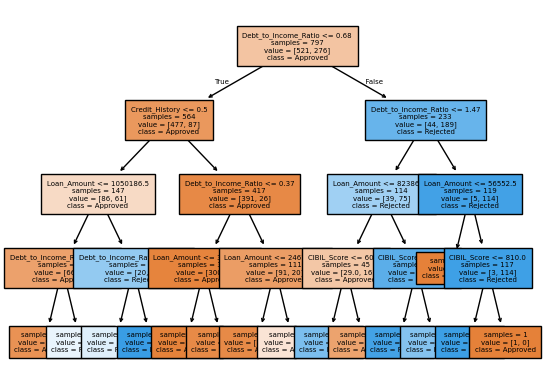

In [14]:
#Visualize Tree
import matplotlib.pyplot as plt
from sklearn import tree
tree.plot_tree(dt, filled=True, feature_names=X.columns, class_names=['Approved', 'Rejected'], fontsize=5, max_depth=4, impurity=False, precision=2)
plt.show()

In [15]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
#Predicting with Random Forest
y_pred_rf = rf.predict(X_test)

In [17]:
#Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1:", f1_score(y_test, y_pred_rf))

Accuracy: 0.825
Precision: 0.7903225806451613
Recall: 0.6901408450704225
F1: 0.7368421052631579


In [18]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)

cm

array([[116,  13],
       [ 22,  49]])

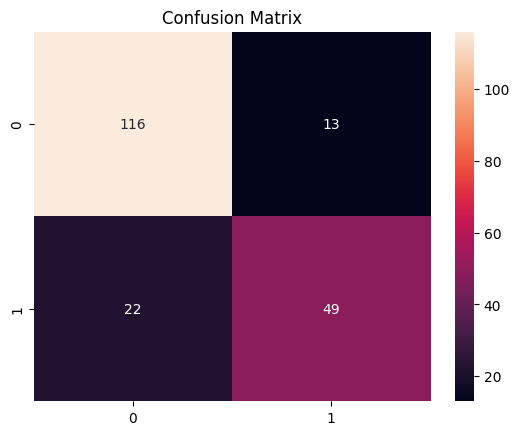

In [19]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [20]:
#Hyperparameter Tuning
#GridSearch CV
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring='f1'
)

grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [25]:
best_rf = grid.best_estimator_

In [26]:
best_pred = best_rf.predict(
    X_test
)

In [28]:
print(
    classification_report(
        y_test,
        best_pred
    )
)

              precision    recall  f1-score   support

           0       0.84      0.91      0.87       129
           1       0.80      0.68      0.73        71

    accuracy                           0.82       200
   macro avg       0.82      0.79      0.80       200
weighted avg       0.82      0.82      0.82       200



In [22]:
#Feature Importance
importance = rf.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feat_imp.sort_values(by='Importance', ascending=False)

,Feature,Importance
6,Debt_to_Income_Ratio,0.315884
0,Applicant_Income,0.188900
2,Loan_Amount,0.140633
5,Existing_EMIs,0.127073
4,CIBIL_Score,0.118502
3,Credit_History,0.061048
1,Coapplicant_Income,0.047960


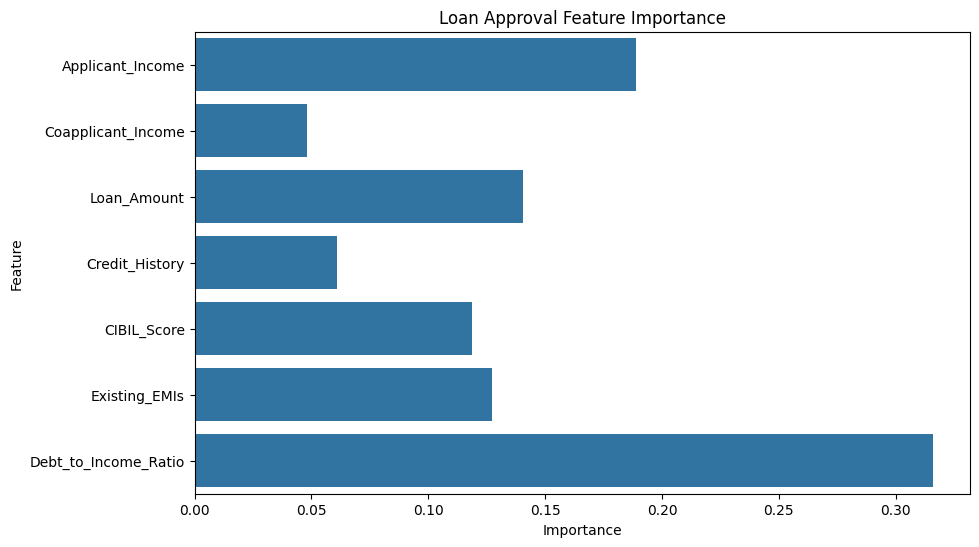

In [29]:
#Visualization for feature Importance
plt.figure(figsize=(10,6))

sns.barplot(
    data=feat_imp,
    x='Importance',
    y='Feature'
)

plt.title(
    "Loan Approval Feature Importance"
)

plt.show()

In [30]:
plt.savefig(
    "../visuals/loan_approval_feature_importance.png"
)

<Figure size 640x480 with 0 Axes>

In [32]:
#Create Model Comparison Table
acc_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

acc_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

acc_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

acc_best = accuracy_score(y_test, best_pred)
precision_best = precision_score(y_test, best_pred)
recall_best = recall_score(y_test, best_pred)
f1_best = f1_score(y_test, best_pred)

results = pd.DataFrame({

'Model':[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Tuned Random Forest'
],

'Accuracy':[
    acc_lr,
    acc_dt,
    acc_rf,
    acc_best
],

'Precision':[
    precision_lr,
    precision_dt,
    precision_rf,
    precision_best
],

'Recall':[
    recall_lr,
    recall_dt,
    recall_rf,
    recall_best
],

'F1 Score':[
    f1_lr,
    f1_dt,
    f1_rf,
    f1_best
]

})

results


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.780,0.736842,0.591549,0.656250
1,Decision Tree,0.810,0.732394,0.732394,0.732394
2,Random Forest,0.825,0.790323,0.690141,0.736842
3,Tuned Random Forest,0.825,0.800000,0.676056,0.732824


In [33]:
#Save Model
import joblib
joblib.dump(
    best_rf,
    "../models/loan_approval_model.pkl"
)

['../models/loan_approval_model.pkl']

In [34]:
#Save Scaler
joblib.dump(
    scaler,
    "../models/loan_approval_scaler.pkl"
)

['../models/loan_approval_scaler.pkl']

In [36]:
#Verify Saved Model
loaded_rf = joblib.load("../models/loan_approval_model.pkl")
loaded_rf.predict(
    X_test.head()
)

array([0, 1, 0, 0, 0])

In [40]:
#Prediction Pipeline
def predict_loan_approval(
        applicant_income,
        coapplicant_income,
        loan_amount,
        credit_history,
        cibil_score,
        existing_emis,
        debt_ratio):
    data = pd.DataFrame({
        'Applicant_Income':[applicant_income],
        'Coapplicant_Income':[coapplicant_income],
        'Loan_Amount':[loan_amount],
        'Credit_History':[credit_history],
        'CIBIL_Score':[cibil_score],
        'Existing_EMIs':[existing_emis],
        'Debt_to_Income_Ratio':[debt_ratio]
    })

    prediction = loaded_model.predict(data)
    return prediction[0]

In [43]:
#Test Pipeline
loaded_model = loaded_rf

predict_loan_approval(
    applicant_income=80000,
    coapplicant_income=25000,
    loan_amount=500000,
    credit_history=1,
    cibil_score=780,
    existing_emis=5000,
    debt_ratio=0.25
)

np.int64(0)